# Day 10: Non-Linear Models & Overfitting

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

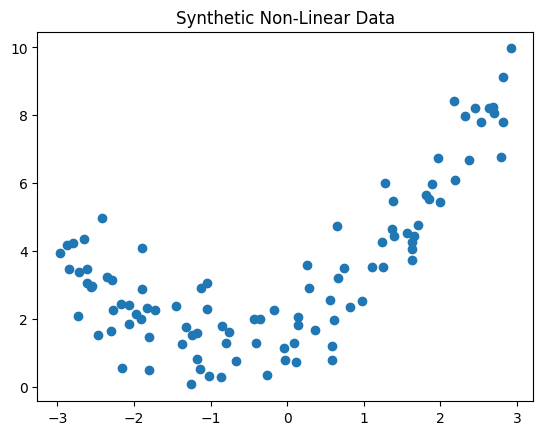

In [2]:
np.random.seed(42)
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(100, 1)

plt.scatter(X, y)
plt.title("Synthetic Non-Linear Data")
plt.show()

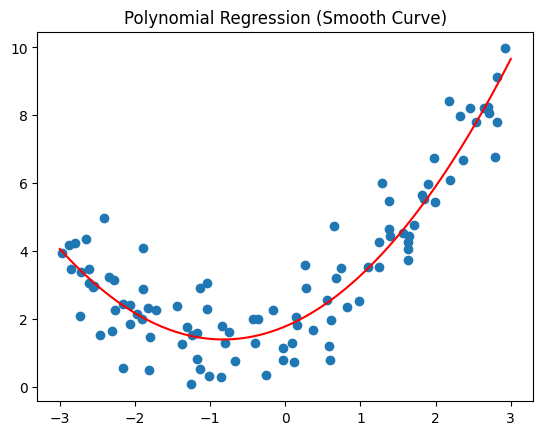

In [3]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly.transform(X_new)
y_poly = model.predict(X_new_poly)

plt.scatter(X, y)
plt.plot(X_new, y_poly, color='red')
plt.title("Polynomial Regression (Smooth Curve)")
plt.show()

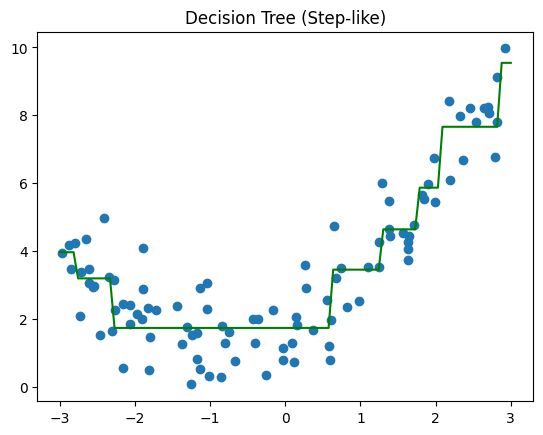

In [4]:
tree = DecisionTreeRegressor(max_depth=3)
tree.fit(X, y)

y_tree = tree.predict(X_new)

plt.scatter(X, y)
plt.plot(X_new, y_tree, color='green')
plt.title("Decision Tree (Step-like)")
plt.show()

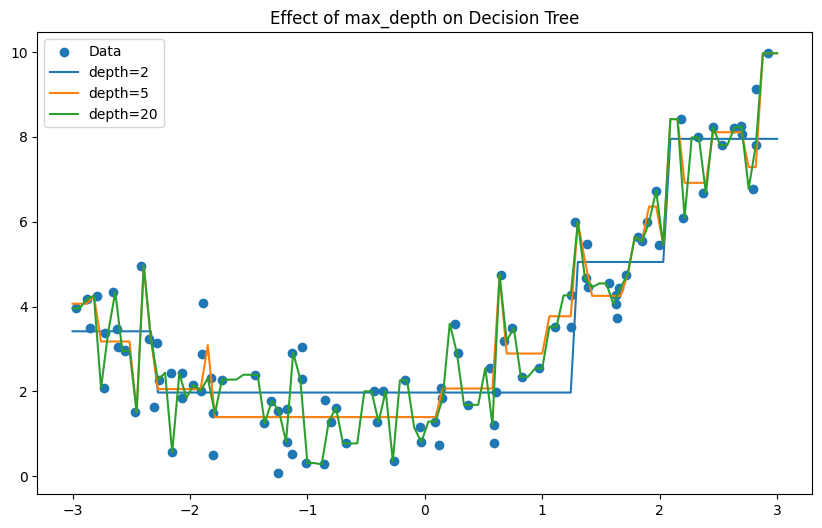

In [5]:
depths = [2, 5, 20]

plt.figure(figsize=(10,6))
plt.scatter(X, y, label="Data")

for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth)
    tree.fit(X, y)
    y_pred = tree.predict(X_new)
    plt.plot(X_new, y_pred, label=f"depth={depth}")

plt.legend()
plt.title("Effect of max_depth on Decision Tree")
plt.show()

In [6]:
# Polynomial R2
poly_r2 = r2_score(y, model.predict(X_poly))
print("Polynomial R2:", poly_r2)

# Tree R2
for depth in depths:
    tree = DecisionTreeRegressor(max_depth=depth)
    tree.fit(X, y)
    r2 = r2_score(y, tree.predict(X))
    print(f"Tree depth {depth} R2:", r2)

Polynomial R2: 0.8525067519009746
Tree depth 2 R2: 0.8132861333394941
Tree depth 5 R2: 0.9294711094168131
Tree depth 20 R2: 1.0


## Observations

- Polynomial Regression captures the overall trend using a smooth curve.
- Decision Tree with depth=2 underfits and fails to capture complexity.
- Depth=5 provides a better balance between bias and variance.
- Depth=20 overfits and produces a highly irregular (jittery) curve.

## Reflection

While experimenting with different models, I noticed that the decision tree with a very high depth (like 20) produced a highly irregular, “jittery” curve that tried to pass through almost every data point. Although this gave a perfect R² score of 1.0 on training data, it made me realize that the model was simply memorizing the data instead of actually learning the underlying pattern.

In contrast, the polynomial regression produced a much smoother curve that did not perfectly fit every point but captured the overall trend effectively. This made it more reliable for unseen data.

So, even though the overfitted model looks more accurate on training data, it is actually worse for real-world predictions because it lacks generalization. A slightly imperfect but smooth model is often more useful than a perfectly fitted but unstable one.